In [76]:
import os
import torch
import torch.nn as nn
from torch.nn.utils import spectral_norm
import torch.optim as optim

from torchvision.datasets import Flowers102
from torchvision import transforms
from torch.utils.data import DataLoader, ConcatDataset

import matplotlib.pyplot as plt
import torchvision.utils as vutils
from torchvision.utils import save_image
import numpy as np
from tqdm import tqdm
import pandas as pd

In [77]:

from google.colab import drive


drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/CGAN_Flowers102-128'
os.makedirs(DRIVE_PATH, exist_ok=True)
os.makedirs(f"{DRIVE_PATH}/output/cgan-images", exist_ok=True)
os.makedirs(f"{DRIVE_PATH}/output/cgan-ckpts/metrics", exist_ok=True)

print(f"Google Drive mounted at: {DRIVE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted at: /content/drive/MyDrive/CGAN_Flowers102-128


In [78]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ADD YOUR HYPERPARAMS HERE!
LATENT_DIM = 100
IMG_SHAPE = (3, 64, 64)  # (c, h, w), we suggest to start with a resolution of 64x64
BATCH_SIZE = 128
LR_G = 0.0002
LR_D = 0.0001
b1 = 0.5
b2 = 0.999
EPOCHS = 150
NUM_CLASSES = 102
EMBEDDING_DIM = 50

SAMPLE_INTERVAL = 200  # generate validation samples every N steps
CKPT_INTERVAL = 5      # save ckpt every M epochs

print(f"Device: {DEVICE}")
print(f"LATENT_DIM: {LATENT_DIM}")
print(f"IMG_SHAPE: {IMG_SHAPE}")
print(f"BATCH_SIZE: {BATCH_SIZE}")
print(f"EPOCHS: {EPOCHS}")

In [79]:
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim, num_classes, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_classes, embedding_dim)

        self.fc = nn.Sequential(
            nn.Linear(latent_dim + embedding_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),

            nn.Linear(1024, 8192),  # 512 * 4 * 4
            nn.BatchNorm1d(8192),
            nn.ReLU(inplace=True),
        )

        self.conv_layers = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),  # → 8x8
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),  # → 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),   # → 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),     # → 64x64
            nn.Tanh()
        )

    def forward(self, z, labels):
        class_emb = self.embedding(labels)
        x = torch.cat([z, class_emb], dim=1)
        x = self.fc(x)
        x = x.view(-1, 512, 4, 4)
        return self.conv_layers(x)

In [80]:
class ConditionalDiscriminator(nn.Module):
   
    def __init__(self, num_classes, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_classes, embedding_dim)

        self.conv_layers = nn.Sequential(
            # (3, 64, 64) → (64, 32, 32)
            spectral_norm(nn.Conv2d(3, 64, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            # → (128, 16, 16)
            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # → (256, 8, 8)
            spectral_norm(nn.Conv2d(128, 256, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # → (512, 4, 4)
            spectral_norm(nn.Conv2d(256, 512, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.fc = nn.Sequential(
            # 512*4*4 + embedding_dim = 8192 + 50
            spectral_norm(nn.Linear(512 * 4 * 4 + embedding_dim, 512)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),  

            spectral_norm(nn.Linear(512, 256)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            spectral_norm(nn.Linear(256, 1)),
            nn.Sigmoid()
        )

    def forward(self, x, labels):
        features  = self.conv_layers(x)
        features  = features.view(features.size(0), -1)
        class_emb = self.embedding(labels)
        x = torch.cat([features, class_emb], dim=1)
        return self.fc(x)

In [81]:
# Loss function
criterion = nn.BCELoss()

# Initialize generator and discriminator
generator = ConditionalGenerator(LATENT_DIM, NUM_CLASSES, EMBEDDING_DIM).to(DEVICE)
discriminator = ConditionalDiscriminator(NUM_CLASSES, EMBEDDING_DIM).to(DEVICE)

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

generator.apply(weights_init)
discriminator.apply(weights_init)

print(f"Generator: {sum(p.numel() for p in generator.parameters()):,} params")
print(f"Discriminator: {sum(p.numel() for p in discriminator.parameters()):,} params")

Generator: 11,811,756 params
Discriminator: 7,145,837 params


In [82]:
# DEFINE THE TRANSFORMS TO APPLY TO IMAGES

transform = transforms.Compose([
    transforms.Resize(64), 
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])



train_set = Flowers102(root='./data', split='train', download=True, transform=transform)
val_set = Flowers102(root='./data', split='val', download=True, transform=transform)
test_set = Flowers102(root='./data', split='test', download=True, transform=transform)

# CONCAT THE 3 PROVIDED SPLITS TO GET A LARGER TRAINING SET (SEE torch.utils.data.ConcatDataset)
full_set = ConcatDataset([train_set, val_set, test_set])

print("Train set: ", len(train_set))
print("Validation set: ", len(val_set))
print("Test set: ", len(test_set))
print("Full set: ", len(full_set))

if hasattr(train_set, "classes"):
    CLASSES = train_set.classes
    print("Number of classes: ", len(set(CLASSES)))

Train set:  1020
Validation set:  1020
Test set:  6149
Full set:  8189
Number of classes:  102


In [83]:
# DEFINE DATALOADERS

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

full_loader = DataLoader(full_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print(f"Full loader batches: {len(full_loader)}")

Full loader batches: 64


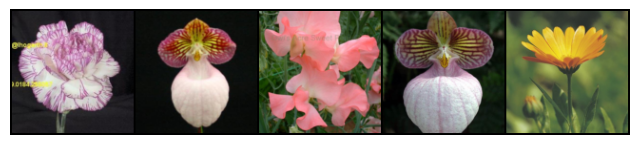

In [84]:
# get one batch
images, labels = next(iter(train_loader))

# make a grid
grid = vutils.make_grid(images[:5], nrow=5, normalize=True)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [85]:
def discriminator_accuracy(real_output, fake_output):

    real_acc = (real_output > 0.5).float().mean()

    fake_acc = (fake_output < 0.5).float().mean()

    # Overall accuracy
    total_acc = (real_acc + fake_acc) / 2
    return real_acc.item(), fake_acc.item(), total_acc.item()

In [86]:
# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR_G, betas=(b1, b2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR_D, betas=(b1, b2))

In [ ]:
# DEFINE THE TRAINING LOOP

# ----------
#  Training
# ----------

#os.makedirs("./output/cgan-images", exist_ok=True)
#os.makedirs("./output/cgan-ckpts", exist_ok=True)

# Sample fixed noise as generator input - to visualize training progress
fixed_z = torch.randn(25, LATENT_DIM).to(DEVICE)
fixed_labels = torch.arange(0, 25) % NUM_CLASSES
fixed_labels = fixed_labels.to(DEVICE)

g_losses = []
d_losses = []
real_accuracies = []
fake_accuracies = []


for epoch in range(EPOCHS):
    for i, (real_images, labels) in enumerate(full_loader):
        real_images = real_images.to(DEVICE)
        labels = labels.to(DEVICE)

        batch_size = real_images.size(0)

        # ---------------------
        #  Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        # Real images
        real_output = discriminator(real_images, labels)
        real_target = torch.ones(batch_size, 1) * 0.9
        d_loss_real = criterion(real_output, real_target)

        # Fake images
        z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
        fake_images = generator(z, labels)
        fake_output = discriminator(fake_images.detach(), labels)
        fake_target = torch.zeros(batch_size, 1) * 0.1
        d_loss_fake = criterion(fake_output, fake_target)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # REMEMBER TO LOG HERE ALSO THE DISCRIMINATOR LOSS AND ACCURACIES ON REAL/FAKE
        real_acc, fake_acc, total_acc = discriminator_accuracy(real_output.detach(), fake_output.detach())
        d_losses.append(d_loss.item())
        real_accuracies.append(real_acc)
        fake_accuracies.append(fake_acc)

        # -----------------
        #  Train Generator
        # -----------------

        optimizer_G.zero_grad()

        z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
        fake_images = generator(z, labels)
        fake_output = discriminator(fake_images, labels)
        g_target = torch.ones(batch_size, 1) * 0.9
        g_loss = criterion(fake_output, g_target)

        g_loss.backward()
        optimizer_G.step()

        # REMEMBER TO LOG HERE ALSO THE GENERATOR LOSS
        g_losses.append(g_loss.item())
        


        print(
            f"[Epoch {epoch}/{EPOCHS}] [Batch {i}/{len(full_loader)}] "
            f"[D loss: {d_loss.item()}] [G loss: {g_loss.item()}] \n"
            f"Real Acc: {real_acc:.3f}  Fake Acc: {fake_acc:.3f}  Total: {total_acc:.3f}"
        )

        steps = epoch * len(full_loader) + i
        if steps % SAMPLE_INTERVAL == 0:
            # Generate a batch of images
            generator.eval()
            with torch.no_grad():
                fake_images_sample = generator(fixed_z, fixed_labels)
            save_image(fake_images_sample.data[:25], f"{DRIVE_PATH}/output/cgan-images/step-{steps}.jpg", nrow=5, normalize=True)
            generator.train()

    if ((epoch+1) % CKPT_INTERVAL) == 0:
        torch.save(generator.state_dict(), f"{DRIVE_PATH}/output/cgan-ckpts/generator_weights_ep-{epoch+1}.pth")
        torch.save(discriminator.state_dict(), f"{DRIVE_PATH}/output/cgan-ckpts/discriminator_weights_ep-{epoch+1}.pth")
        metrics_dir = f"{DRIVE_PATH}/output/dcgan-ckpts/metrics"
        os.makedirs(metrics_dir, exist_ok=True)
        metrics_df = pd.DataFrame({
            'g_losses': g_losses,
            'd_losses': d_losses,
            'real_acc': real_accuracies,
            'fake_acc': fake_accuracies
        })
        csv_save_path = f"{metrics_dir}/metrics.csv"
        metrics_df.to_csv(csv_save_path, index=False)

In [89]:
# PLOT GENERATOR AND DISCRIMINATOR LOSSES

csv_path = f"{DRIVE_PATH}/output/cgan-ckpts/metrics/metrics.csv"
df = pd.read_csv(csv_path)
fig, ax = plt.subplots(figsize=(10, 5))


ax.plot(df['g_losses'], label='Generator Loss')
ax.plot(df['d_losses'], label='Discriminator Loss')


ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('CGAN Losses')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/losses.jpg', dpi=150)
plt.show()

In [88]:
# PLOT REAL AND FAKE ACCURACIES


csv_path = f"{DRIVE_PATH}/output/cgan-ckpts/metrics/metrics.csv"
df = pd.read_csv(csv_path)
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df['real_acc'], color='green', alpha=0.2, label='Real Acc (Raw)')
ax.plot(df['fake_acc'], color='red', alpha=0.2, label='Fake Acc (Raw)')

ax.plot(df['real_acc'].rolling(window=10).mean(), color='green', linewidth=2, label='Real Acc (Trend)')
ax.plot(df['fake_acc'].rolling(window=10).mean(), color='red', linewidth=2, label='Fake Acc (Trend)')



ax.set_xlabel('Iteration')
ax.set_ylabel('Accuracy')
ax.set_title('Discriminator Accuracies')
ax.set_ylim([0, 1])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/accuracies.jpg', dpi=150)
plt.show()


In [91]:

epochs_to_compare = [0, 10, 30, 50, 75, 100, 125, 150]
num_samples       = 8
compare_labels    = (torch.arange(0, num_samples) % NUM_CLASSES).to(DEVICE)

fig, axes = plt.subplots(len(epochs_to_compare) + 1, 1,
                         figsize=(16, 3.5 * (len(epochs_to_compare) + 1)))


real_batch, _ = next(iter(full_loader))
real_grid     = vutils.make_grid(real_batch[:num_samples], nrow=num_samples, normalize=True)
axes[0].imshow(real_grid.permute(1, 2, 0).cpu())
axes[0].set_title('Real images', fontsize=13, fontweight='bold')
axes[0].axis('off')

for idx, ep in enumerate(epochs_to_compare):
    ax    = axes[idx + 1]
    path  = f'{DRIVE_PATH}/output/cgan-ckpts/generator_weights_ep-{ep}.pth'

    gen_tmp = ConditionalGenerator(LATENT_DIM, NUM_CLASSES, EMBEDDING_DIM).to(DEVICE)

    if ep == 0:
        title = 'Epoch 0: Random initialization'
    elif os.path.exists(path):
        gen_tmp.load_state_dict(torch.load(path, map_location=DEVICE))
        title = f'Epoch {ep}'
    else:
        ax.text(0.5, 0.5, f'Epoch {ep} — not found', ha='center', va='center')
        ax.axis('off')
        continue

    gen_tmp.eval()
    with torch.no_grad():
        fake = gen_tmp(fixed_z[:num_samples], compare_labels)
    grid = vutils.make_grid(fake, nrow=num_samples, normalize=True)
    ax.imshow(grid.permute(1, 2, 0).cpu())
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.suptitle('cGAN Quality Progression', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
save_path = f'{DRIVE_PATH}/cgan_progression.jpg'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Progression grid saved at: {save_path}')